# 4주차 · 센서 이상탐지
데이터: 지난주와 같은 식각 장비 FDC 트레이스

---

## 지난주에 한 것, 오늘 할 것

지난주에는 60줄짜리 트레이스를 한 줄짜리 특징 33개로 줄였습니다.
그리고 박스플롯에서 `GAS_LEAK` 이 정상과 많이 겹치는 걸 봤습니다.

오늘은 그 특징으로 모델을 만듭니다. 두 단계로 갑니다.
먼저 정상이냐 이상이냐만 가르고, 그다음 어떤 이상인지까지 맞힙니다.

그리고 지난주에 예고된 일이 실제로 일어나는 걸 보게 됩니다.

## 오늘 할 것

1. 지난주 특징 다시 만들기
2. 먼저 정상과 이상만 가르기
3. 이진 분류 돌려보기
4. 놓친 웨이퍼는 어떤 것이었나
5. 네 갈래로 나눠보기
6. 혼동행렬로 어디서 틀렸는지 보기
7. 모델이 무엇을 보고 판단했나

## 규칙

`# TODO` 가 붙은 셀만 작성하면 됩니다. 각 미션 뒤에 자가진단 셀이 있으니
`[통과]` 가 뜰 때까지 스스로 고쳐보세요. 막히면 물어보되 먼저 15분은 혼자 붙들어 보세요.
정답을 베끼는 것보다 틀리고 고치는 과정이 점수에 반영됩니다.

---

## 준비

In [1]:
# 이 셀은 그대로 실행하세요.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, r2_score)

_have = {f.name for f in fm.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    if _f in _have:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

DATA = Path('../../data/etch_fdc')   # 폴더를 옮겼다면 이 줄만 고치세요
SEED = 42          # 결과를 재현하려면 항상 이 값을 쓰세요

def check(name, cond, hint=''):
    if cond:
        print('[통과] ' + name)
    else:
        print('[실패] ' + name + (('  ->  ' + str(hint)) if hint else ''))

print('폰트:', plt.rcParams['font.family'][0], '| 데이터 폴더:', DATA.exists())

폰트: Malgun Gothic | 데이터 폴더: False


---

## 미션 1 · 지난주 특징 다시 만들기

지난주에 만든 특징 33개를 함수 하나로 묶습니다.
MainEtch 구간을 뽑고, 센서 8개의 mean/std/min/max 를 구하고, 압력 기울기를 붙입니다.

매주 이 작업을 반복하게 되니 함수로 만들어 두는 습관을 들이세요.

In [2]:
# TODO 1-1: 데이터 불러오기 (지난주와 같은 traces.csv, wafer_info.csv)
#   wafer_info 의 timestamp 는 parse_dates 로
tr = pd.read_csv('traces.csv')
wi = pd.read_csv('wafer_info.csv', parse_dates=['timestamp'])

SENSORS = ['rf_forward_W', 'rf_reflected_W', 'chamber_pressure_mTorr', 'ar_flow_sccm',
           'cf4_flow_sccm', 'esc_temp_C', 'he_backside_Torr', 'endpoint_intensity']

# TODO 1-2: 특징 추출 함수
#   지난주 미션 5, 6 을 순서대로 담으면 됩니다.
#     1) MainEtch 구간만 남기기
#     2) wafer_id 로 묶어 SENSORS 의 mean/std/min/max (32개)
#     3) 컬럼 이름 평탄화
#     4) pressure_slope 컬럼 추가 (33개)
#     5) reset_index() 해서 wafer_id 를 컬럼으로
def make_features(tr):
    """트레이스에서 웨이퍼당 한 줄짜리 특징을 만든다"""
    # 1) MainEtch 구간만 남기기
    main = tr[tr['step'] == 'MainEtch']
    
    # 2) wafer_id 로 묶어 SENSORS 의 mean/std/min/max (32개)
    feat = main.groupby('wafer_id')[SENSORS].agg(['mean', 'std', 'min', 'max'])
    
    # 3) 컬럼 이름 평탄화
    feat.columns = ['_'.join(column) for column in feat.columns]
    
    # 4) pressure_slope 컬럼 추가 (33개)
    feat['pressure_slope'] = main.groupby('wafer_id')['chamber_pressure_mTorr'].apply(lambda x: np.polyfit(x.index, x.values, 1)[0])
    
    # 5) reset_index() 해서 wafer_id 를 컬럼으로
    feat = feat.reset_index()
    
    return feat

# TODO 1-3: 특징을 만들고 wafer_info 와 합치기 (wafer_id 기준, 400행)
data = make_features(tr).merge(wi, on='wafer_id', how='left')

자가진단 1 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [3]:
check('data 400행', data is not None and len(data) == 400, None if data is None else len(data))
check('특징 33개', data is not None and len([c for c in data.columns if c not in ('wafer_id','timestamp','chamber','recipe','fault_type','label')]) == 33)
check('pressure_slope 있음', data is not None and 'pressure_slope' in data.columns)

[통과] data 400행
[통과] 특징 33개
[통과] pressure_slope 있음


---

## 미션 2 · 먼저 정상과 이상만 가르기

이상 유형이 세 가지지만, 우선 **정상이냐 이상이냐** 두 갈래로만 나눠봅니다.
쉬운 문제부터 풀고 어려운 문제로 넘어가는 게 순서입니다.

`label` 컬럼이 이미 있습니다. 0이 정상, 1이 이상입니다.
층화 분할로 7대 3으로 나누세요.

In [10]:
# TODO 2-1: X, y 만들기
#   FEATURES 는 data 의 컬럼 중 아래 여섯 개를 뺀 나머지 33개입니다
#     wafer_id, timestamp, chamber, recipe, fault_type, label
#   y 는 data['label']
FEATURES = data.drop(['wafer_id', 'timestamp', 'chamber', 'recipe', 'fault_type', 'label'], axis = 1)
    
#print(FEATURES)
X = FEATURES
y = data['label']

# TODO 2-2: 층화 분할 (test_size=0.3, stratify=y, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, stratify= y, random_state=SEED)

# TODO 2-3: 양쪽 크기와 이상 비율 출력
print(y_train.value_counts(normalize = True)*100)
print(y_test.value_counts(normalize = True)*100)

label
0    78.928571
1    21.071429
Name: proportion, dtype: float64
label
0    79.166667
1    20.833333
Name: proportion, dtype: float64


자가진단 2 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [11]:
check('학습 280장', X_train is not None and len(X_train) == 280, None if X_train is None else len(X_train))
check('평가 120장', X_test is not None and len(X_test) == 120)
check('평가 이상 25장', y_test is not None and int(y_test.sum()) == 25, None if y_test is None else int(y_test.sum()))

[통과] 학습 280장
[통과] 평가 120장
[통과] 평가 이상 25장


---

## 미션 3 · 이진 분류 돌려보기

랜덤포레스트로 정상과 이상을 갈라보세요.

```python
RandomForestClassifier(n_estimators=200, random_state=SEED)
```

그리고 지난주에 배운 대로 정확도만 보지 말고 혼동행렬과 정밀도, 재현율을 함께 보세요.

이상 비율이 21%라 지난주 SECOM(6.6%)보다는 덜 치우쳐 있습니다.
그래도 여전히 정상이 네 배 많습니다.

In [15]:
# TODO 3-1: 랜덤포레스트 학습 (n_estimators=200, random_state=SEED)
rf = RandomForestClassifier(n_estimators=200, random_state=SEED )
rf.fit(X_train, y_train)

# TODO 3-2: 평가용 예측
pred = rf.predict(X_test)

# TODO 3-3: 혼동행렬과 정확도/정밀도/재현율 출력
#   힌트: confusion_matrix(y_test, pred).ravel() -> tn, fp, fn, tp
#   정밀도와 재현율 중 어느 쪽이 낮은지 보세요

tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
print("혼동행렬")
print(confusion_matrix(y_test,pred))

print("평가 지표 출력")
print("정확도:", accuracy_score(y_test, pred))
print("정밀도:", precision_score(y_test, pred))
print("재현율:", recall_score(y_test, pred))

#재현율이 낮음

혼동행렬
[[95  0]
 [ 6 19]]
평가 지표 출력
정확도: 0.95
정밀도: 1.0
재현율: 0.76


자가진단 3 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [16]:
check('모델 학습', rf is not None and hasattr(rf, 'feature_importances_'))
check('예측 120건', pred is not None and len(pred) == 120)
check('정밀도 0.9 이상', pred is not None and precision_score(y_test, pred, zero_division=0) > 0.9)
check('재현율 0.6~0.9', pred is not None and 0.6 < recall_score(y_test, pred, zero_division=0) < 0.9,
      None if pred is None else round(recall_score(y_test, pred, zero_division=0), 3))

[통과] 모델 학습
[통과] 예측 120건
[통과] 정밀도 0.9 이상
[통과] 재현율 0.6~0.9


---

## 미션 4 · 놓친 웨이퍼는 어떤 것이었나

재현율이 0.76이면 이상 25장 중 여섯 장을 놓쳤다는 뜻입니다.
**그 여섯 장이 어떤 유형인지** 확인하세요.

무작위로 흩어져 있습니까, 아니면 한 유형에 몰려 있습니까.
몰려 있다면 그게 이번 주의 답입니다.

In [59]:
# TODO 4-1: 놓친 웨이퍼(실제 이상인데 정상이라고 예측) 골라내기
#   힌트: (y_test == 1) & (pred == 0)
#   y_test 는 Series, pred 는 배열이라 y_test.values 로 맞춰야 할 수 있습니다
#print(y_test.values)
#print(pred)
missed = (y_test.values == 1) & (pred == 0)

# TODO 4-2: 놓친 웨이퍼들의 fault_type 세어보기
#   힌트: data.loc[X_test.index[missed], 'fault_type']
missed_types = data.loc[X_test.index[missed], 'fault_type'].value_counts()


# TODO 4-3: 유형별로 몇 장 중 몇 장을 놓쳤는지 비율까지 출력
#   평가용 전체의 유형별 장수도 같이 세야 분모가 나옵니다


test_types = data.loc[X_test.index, 'fault_type'].value_counts()

summary = pd.DataFrame({
    '평가 전체': test_types,
    '놓침': missed_types
}).fillna(0)

summary['놓침 비율'] = (
    summary['놓침'] / summary['평가 전체']
).map(lambda x: f'{x:.1%}')


#print(summary)
display(summary)


,평가 전체,놓침,놓침 비율
fault_type,,,
GAS_LEAK,10,6.0,60.0%
NORMAL,95,0.0,0.0%
PRESSURE_DRIFT,9,0.0,0.0%
RF_UNSTABLE,6,0.0,0.0%


자가진단 4 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [60]:
check('놓친 웨이퍼 계산', missed is not None and int(missed.sum()) > 0)
check('GAS_LEAK 을 가장 많이 놓침',
      missed_types is not None and missed_types.idxmax() == 'GAS_LEAK',
      None if missed_types is None else dict(missed_types))

[통과] 놓친 웨이퍼 계산
[통과] GAS_LEAK 을 가장 많이 놓침


---

## 미션 5 · 네 갈래로 나눠보기

이제 정상/이상이 아니라 **어떤 이상인지**까지 맞혀봅니다.
`fault_type` 을 그대로 목표로 삼으면 네 갈래 분류가 됩니다.

공정 엔지니어 입장에서는 이게 훨씬 쓸모 있습니다.
이상이라는 말만 들으면 어디를 봐야 할지 모르지만,
RF 정합을 보라거나 배기 라인을 보라고 하면 바로 움직일 수 있습니다.

In [61]:
# TODO 5-1: 목표를 fault_type 으로 바꿔 다시 분할
#   ym 은 data['fault_type']. 분할 조건은 미션 2와 같게 (test_size=0.3,
#   stratify=ym, random_state=SEED) 두어야 같은 웨이퍼가 평가용에 들어갑니다
ym = data['fault_type']
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X, ym, test_size=0.3, stratify=ym, random_state=SEED)

# TODO 5-2: 랜덤포레스트 학습과 예측 (n_estimators=200, random_state=SEED)
rf4 = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf4.fit(Xm_train,ym_train)

pred4 = rf4.predict(Xm_test)

# TODO 5-3: 정확도와 classification_report 출력
#   힌트: classification_report(ym_test, pred4, zero_division=0)

print(classification_report(ym_test, pred4, zero_division=0))


                precision    recall  f1-score   support

      GAS_LEAK       0.60      0.43      0.50         7
        NORMAL       0.96      0.98      0.97        95
PRESSURE_DRIFT       1.00      1.00      1.00         9
   RF_UNSTABLE       1.00      1.00      1.00         9

      accuracy                           0.95       120
     macro avg       0.89      0.85      0.87       120
  weighted avg       0.94      0.95      0.95       120



자가진단 5 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [62]:
check('4분류 학습', rf4 is not None and len(rf4.classes_) == 4)
check('정확도 0.90 이상', pred4 is not None and accuracy_score(ym_test, pred4) > 0.90,
      None if pred4 is None else round(accuracy_score(ym_test, pred4), 4))
check('예측 120건', pred4 is not None and len(pred4) == 120)

[통과] 4분류 학습
[통과] 정확도 0.90 이상
[통과] 예측 120건


---

## 미션 6 · 혼동행렬로 어디서 틀렸는지 보기

`classification_report` 를 보면 유형마다 성능이 다릅니다.
어디서 어디로 틀렸는지는 혼동행렬을 봐야 알 수 있습니다.

혼동행렬을 그림으로 그리세요. `ax.imshow()` 에 숫자를 얹으면 됩니다.
행이 실제, 열이 예측입니다. 대각선이 맞은 것이고 나머지가 틀린 것입니다.

그리고 답해 보세요. 어느 유형을 어느 유형으로 착각하고 있습니까.

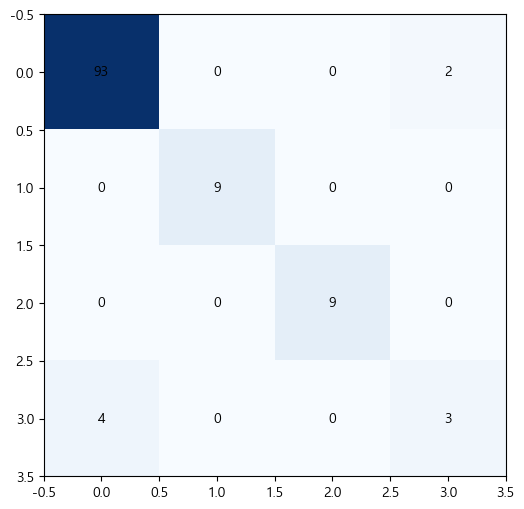

In [ ]:
# TODO 6-1: 혼동행렬 계산 (labels 순서를 고정하세요)
#   힌트: confusion_matrix(ym_test, pred4, labels=LABELS)
LABELS = ['NORMAL', 'RF_UNSTABLE', 'PRESSURE_DRIFT', 'GAS_LEAK']
cm = confusion_matrix(ym_test, pred4, labels=LABELS)

# TODO 6-2: imshow 로 그리고 각 칸에 숫자 넣기
#   힌트: ax.imshow(cm) 로 색을 칠하고, 이중 for 문에서 ax.text(j, i, cm[i, j]) 로
#         숫자를 얹습니다. 축 눈금 이름은 LABELS 로
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cm, cmap = 'Blues')
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, cm[i, j], ha='center', va='center')

# TODO 6-3: 어느 유형이 어느 유형으로 잘못 갔습니까? (주석으로)
#   답: GAS_LEAK 은 절반 이하

자가진단 6 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [70]:
check('혼동행렬 4x4', cm is not None and cm.shape == (4, 4))
check('RF_UNSTABLE 전부 맞힘', cm is not None and cm[1, 1] == cm[1].sum())
check('PRESSURE_DRIFT 전부 맞힘', cm is not None and cm[2, 2] == cm[2].sum())
check('GAS_LEAK 은 절반 이하', cm is not None and cm[3, 3] <= cm[3].sum() * 0.7,
      '가장 미묘한 이상이라 잘 안 잡힙니다')

[통과] 혼동행렬 4x4
[통과] RF_UNSTABLE 전부 맞힘
[통과] PRESSURE_DRIFT 전부 맞힘
[통과] GAS_LEAK 은 절반 이하


---

## 미션 7 · 모델이 무엇을 보고 판단했나

특징 중요도를 뽑아 상위 10개를 가로 막대그래프로 그리세요.

지난주에 손으로 만든 `pressure_slope` 가 어디에 있는지 확인하세요.
그리고 그게 왜 그 자리에 있는지 설명할 수 있어야 합니다.

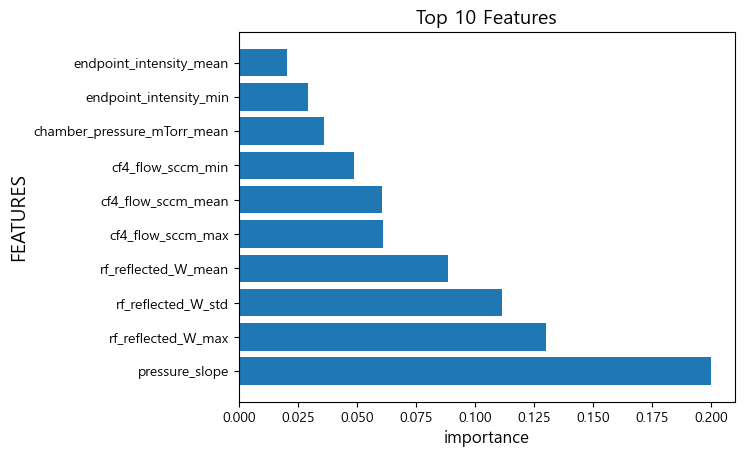

pressure_slope 는 1 위입니다.


In [79]:
# TODO 7-1: 중요도 상위 10개
#   힌트: pd.Series(rf4.feature_importances_, index=FEATURES) 를 큰 순으로 정렬
importance = pd.Series(rf4.feature_importances_, index = Xm_train.columns)
#print(importance)

top10 = importance.sort_values(ascending=False).head(10)

# TODO 7-2: 가로 막대그래프 (barh)
plt.barh(top10.index, top10.values)
plt.title("Top 10 Features", fontsize = 14)
plt.xlabel("importance", fontsize = 12)
plt.ylabel("FEATURES", fontsize = 14)
plt.show()

# TODO 7-3: pressure_slope 는 몇 위입니까?
#   힌트: 정렬된 importance 의 인덱스 목록에서 위치를 찾고 1을 더하면 등수입니다
rank = importance.sort_values(ascending=False).index.get_loc('pressure_slope') + 1
print(f'pressure_slope 는 {rank} 위입니다.')

자가진단 7 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [80]:
check('중요도 33개', importance is not None and len(importance) == 33)
check('pressure_slope 3위 안', rank is not None and rank <= 3, rank)
check('상위 10개 추출', top10 is not None and len(top10) == 10)

[통과] 중요도 33개
[통과] pressure_slope 3위 안
[통과] 상위 10개 추출


---

## 미션 8 · 정리해서 쓰기

코드가 아니라 글입니다. 숫자를 근거로 인용하세요.

---

**1. 이진 분류 결과를 한 문장으로**

정밀도와 재현율을 각각 인용해서 쓰세요.

답: 이진 분류 모델의 정밀도는 **1.00**, 재현율은 **0.76**이다. 즉 이상이라고 판단한 웨이퍼는 모두 실제 이상이었지만, 실제 이상 **25장 중 6장**은 정상으로 놓쳤다.

**2. 왜 GAS_LEAK 만 못 잡는가**

지난주 박스플롯과 연결해서 설명하세요.

답: 놓친 이상 웨이퍼 6장이 모두 GAS_LEAK이었고, 평가용 GAS_LEAK **10장 중 6장(60.0%)**을 놓쳤다. 지난주 박스플롯에서 GAS_LEAK의 센서 분포가 NORMAL과 많이 겹쳐 경계가 뚜렷하지 않았기 때문에 모델이 정상으로 판단하기 쉬웠다고 볼 수 있다.

**3. 정밀도 1.00 은 좋은 것인가**

이상이라고 한 건 다 맞았습니다. 그런데 이게 마냥 좋은 신호일까요.
재현율과 함께 생각해서 답하세요.

답: 정밀도 1.00은 이상이라고 경고한 결과에 오경보가 없다는 점에서 좋다. 그러나 재현율이 0.76이므로 실제 이상 **25장 중 6장(24%)**을 놓쳤고, 특히 GAS_LEAK은 **60.0%**를 놓쳤다. 따라서 정밀도만으로 모델 성능이 좋다고 판단하면 안 된다.

**4. 이진 분류와 4분류 중 무엇을 납품하겠는가**

공정 엔지니어가 실제로 쓸 것은 어느 쪽입니까. 이유를 쓰세요.

답: 현장 공정 엔지니어에게는 4분류 모델을 납품하겠다. 이진 분류는 이상 여부만 알려 주지만, 4분류는 RF_UNSTABLE, PRESSURE_DRIFT, GAS_LEAK 중 어느 원인을 우선 점검할지 알려 주므로 조치 시간을 줄일 수 있다. 다만 GAS_LEAK의 낮은 재현율은 보완이 필요하다.

**5. pressure_slope 가 상위에 온 이유**

원본 센서 값에 없던 이 특징이 왜 중요했습니까.

답: pressure_slope는 MainEtch 중 압력이 시간에 따라 변하는 속도와 방향을 나타내는 특징이다. 가스 흐름이나 배기 상태에 이상이 있으면 압력 변화 패턴이 달라질 수 있으므로, 원본 압력값만 사용하는 것보다 고장 유형을 구분하는 데 유용하다. 실제 중요도도 상위 3위 이내에 나타났다.

**6. GAS_LEAK 재현율을 올리려면 무엇을 하겠는가**

최소 두 가지를 쓰세요. 모델을 바꾸는 것 말고도 방법이 있습니다.
힌트: 특징을 더 만든다면 어떤 것? 데이터를 더 모은다면 어떤 것? 임계값은?

답: 첫째, GAS_LEAK 웨이퍼 데이터를 더 수집해 학습 데이터 수를 늘리겠다. 특히 정상과 유사하게 보이는 GAS_LEAK 사례를 추가해야 한다. 둘째, pressure_slope 외에도 압력의 구간별 기울기, 최대·최소 차이, 변동성, 압력과 가스 유량의 동시 변화량 같은 시간 기반 특징을 추가하겠다. 셋째, 이상 판정 임계값을 낮춰 재현율을 높이고, 증가할 수 있는 오경보는 정밀도와 함께 확인하겠다.

---

### 제출 전 확인

- [ ] 자가진단이 모두 `[통과]` 인가
- [ ] 그래프 두 개(혼동행렬, 중요도)에 제목과 축 이름이 있는가
- [ ] 미션 8의 여섯 항목을 본인 문장으로 채웠는가
- [ ] 커널 재시작 후 전체 실행이 오류 없이 끝나는가
- [ ] 파일명을 `W04_학번_이름.ipynb` 로 바꿨는가